## Getting rating curves from different streams in VCNP

Import data

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from scipy.stats import linregress

lajara_2021 = pd.read_csv("la_jara/discharge_2021.csv", parse_dates=[0], index_col=0, na_values=['NaN']) # first column is datetime and second column is discharge in m3/s
lajara_2022 = pd.read_csv("la_jara/discharge_2022.csv", parse_dates=[0], index_col=0, na_values=['NaN']) # m3/s
lajara_2023 = pd.read_csv("la_jara/discharge_2023.csv", parse_dates=[0], index_col=0, na_values=['NaN']) # m3/s
redondo = pd.read_csv("redondo/DataSetExport-Discharge.Discharge@VALL_MIRLKE-Maximum-ft^3 s-20260223140410.csv", parse_dates=[0], index_col=0, na_values=['NaN']) # ft^3/s
san_antonio = pd.read_csv("san_antonio/DataSetExport-Discharge.Discharge@VALL_RSAWES-Maximum-ft^3 s-20260302191152.csv", parse_dates=[0], index_col=0, na_values=['NaN']) # ft^3/s
lower_sulphur = pd.read_csv("lower_sulphur/DataSetExport-Discharge.Discharge (Daily Mean)@VALL_LWRSUL-Maximum-ft^3 s-20260302190628.csv", parse_dates=[0], index_col=0, na_values=['NaN'])
upper_sulphur = pd.read_csv("upper_sulphur/DataSetExport-Discharge.Discharge@VALL_UPRSUL-Maximum-ft^3 s-20260302181951.csv", parse_dates=[0], index_col=0, na_values=['NaN']) # ft^3/s

In [2]:
# convert ft^3/s to m3/s for redondo, san_antonio, lower_sulphur, and upper_sulphur
redondo["redondo (m3/s)"] = redondo["Value (ft^3/s)"] * 0.0283168
san_antonio["san_antonio (m3/s)"] = san_antonio["Value (ft^3/s)"] * 0.0283168
lower_sulphur["lower_sulphur (m3/s)"] = lower_sulphur["Value (ft^3/s)"] * 0.0283168
upper_sulphur["upper_sulphur (m3/s)"] = upper_sulphur["Value (ft^3/s)"] * 0.0283168

# la jara data as base 
lajara_2021.rename(columns={'Q': 'la_jara'}, inplace=True)
lajara_2022.rename(columns={'Q': 'la_jara'}, inplace=True)
lajara_2023.rename(columns={'Q': 'la_jara'}, inplace=True)

## 2021

In [3]:
# merge all onto la_jara 2021 index (inner join to only keep dates available in la_jara_2021)
merged_2021 = lajara_2021.copy()
merged_2021 = merged_2021.join([
    redondo[['redondo (m3/s)']],
    san_antonio[['san_antonio (m3/s)']],
    lower_sulphur[['lower_sulphur (m3/s)']],
    upper_sulphur[['upper_sulphur (m3/s)']]
], how='left')

print(merged_2021.head())
print(f"Shape: {merged_2021.shape}")

                      la_jara  redondo (m3/s)  san_antonio (m3/s)  \
2021-07-01 00:00:00  0.004673        0.005916            0.112342   
2021-07-01 00:15:00  0.004673        0.005707            0.114706   
2021-07-01 00:30:00  0.004673        0.006074            0.115023   
2021-07-01 00:45:00  0.004687        0.005827            0.116137   
2021-07-01 01:00:00  0.004702        0.005756            0.116937   

                     lower_sulphur (m3/s)  upper_sulphur (m3/s)  
2021-07-01 00:00:00              0.009846              0.009117  
2021-07-01 00:15:00                   NaN              0.008949  
2021-07-01 00:30:00                   NaN              0.008478  
2021-07-01 00:45:00                   NaN              0.009191  
2021-07-01 01:00:00                   NaN              0.008987  
Shape: (7586, 5)


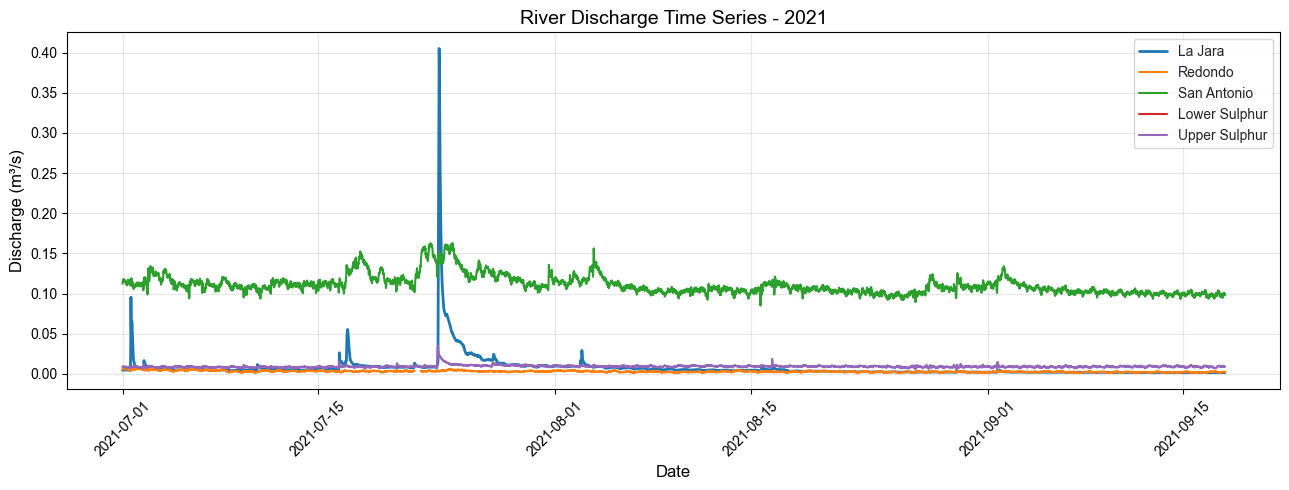

In [4]:
fig, ax = plt.subplots(figsize=(13, 5))
sns.set_style("whitegrid")

ax.plot(merged_2021.index, merged_2021['la_jara'], label='La Jara', linewidth=2)
ax.plot(merged_2021.index, merged_2021['redondo (m3/s)'], label='Redondo', linewidth=1.5)
ax.plot(merged_2021.index, merged_2021['san_antonio (m3/s)'], label='San Antonio', linewidth=1.5)
ax.plot(merged_2021.index, merged_2021['lower_sulphur (m3/s)'], label='Lower Sulphur', linewidth=1.5)
ax.plot(merged_2021.index, merged_2021['upper_sulphur (m3/s)'], label='Upper Sulphur', linewidth=1.5)

ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Discharge (m³/s)', fontsize=12)
ax.set_title('River Discharge Time Series - 2021', fontsize=14)
ax.legend(loc='best')
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

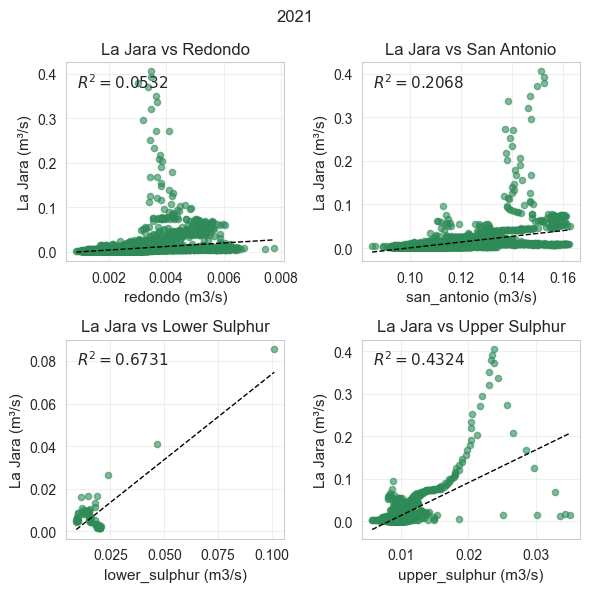

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(6, 6))
fig.suptitle('2021', fontsize=12)
sns.set_style("whitegrid")

# define the pairs: (x_column, subplot_position, title)
pairs = [
    ('redondo (m3/s)', axes[0, 0], 'La Jara vs Redondo'),
    ('san_antonio (m3/s)', axes[0, 1], 'La Jara vs San Antonio'),
    ('lower_sulphur (m3/s)', axes[1, 0], 'La Jara vs Lower Sulphur'),
    ('upper_sulphur (m3/s)', axes[1, 1], 'La Jara vs Upper Sulphur')
]

for x_col, ax, title in pairs:
    # remove NaN values for the regression
    valid_data = merged_2021[[x_col, 'la_jara']].dropna()
    # scatter plot
    ax.scatter(valid_data[x_col], valid_data['la_jara'], alpha=0.6, s=20, color='seagreen')
    # Linear regression
    slope, intercept, r_value, p_value, std_err = linregress(valid_data[x_col], valid_data['la_jara'])
    r2 = r_value**2
    
    # plot regression line
    x_line = np.array([valid_data[x_col].min(), valid_data[x_col].max()])
    y_line = slope * x_line + intercept
    ax.plot(x_line, y_line, color='black', linestyle='--', linewidth=1)
    
    # Labels and title with R² value
    ax.set_xlabel(x_col, fontsize=11)
    ax.set_ylabel('La Jara (m³/s)', fontsize=11)
    ax.set_title(title, fontsize=12)
    ax.text(0.05, 0.95, f'$R^2 = {r2:.4f}$', transform=ax.transAxes, fontsize=11, verticalalignment='top')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 2022

In [7]:
merged_2022 = lajara_2022.copy()
merged_2022 = merged_2022.join([
    redondo[['redondo (m3/s)']],
    san_antonio[['san_antonio (m3/s)']],
    lower_sulphur[['lower_sulphur (m3/s)']],
    upper_sulphur[['upper_sulphur (m3/s)']]
], how='left')

print(merged_2022.tail())
print(f"Shape: {merged_2022.shape}")

                      la_jara  redondo (m3/s)  san_antonio (m3/s)  \
2022-09-16 23:00:00  0.006394        0.004184            0.128803   
2022-09-16 23:15:00  0.006674        0.003877            0.130703   
2022-09-16 23:30:00  0.006674        0.004030            0.129603   
2022-09-16 23:45:00  0.005989        0.004373            0.129962   
2022-09-17 00:00:00  0.006677        0.004693            0.130063   

                     lower_sulphur (m3/s)  upper_sulphur (m3/s)  
2022-09-16 23:00:00                   NaN              0.005396  
2022-09-16 23:15:00                   NaN              0.005235  
2022-09-16 23:30:00                   NaN              0.005479  
2022-09-16 23:45:00                   NaN              0.005096  
2022-09-17 00:00:00              0.026713              0.004341  
Shape: (12648, 5)


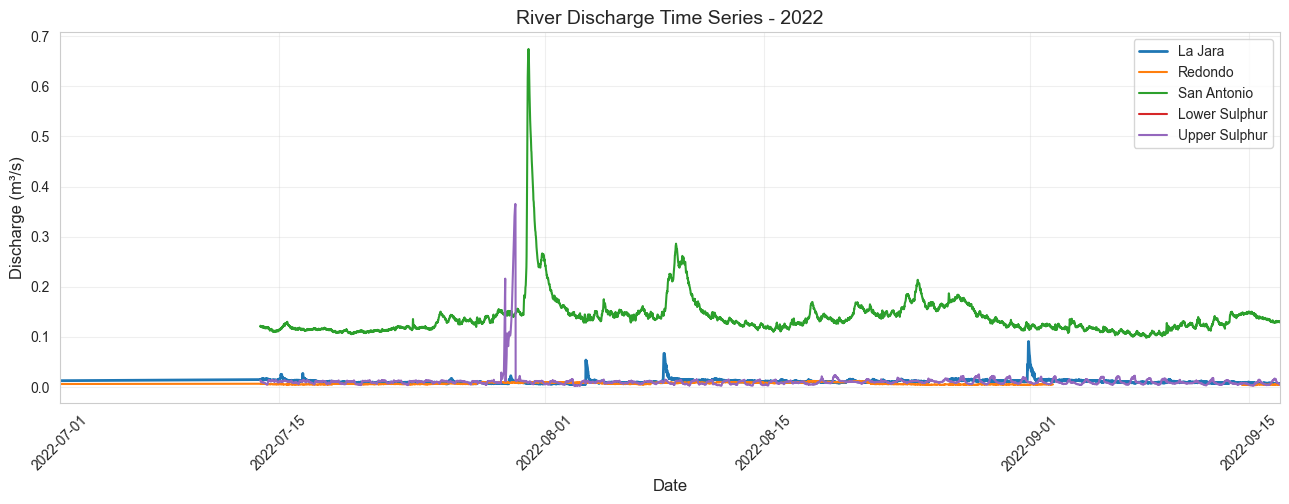

In [10]:
fig, ax = plt.subplots(figsize=(13, 5))
sns.set_style("whitegrid")

ax.plot(merged_2022.index, merged_2022['la_jara'], label='La Jara', linewidth=2)
ax.plot(merged_2022.index, merged_2022['redondo (m3/s)'], label='Redondo', linewidth=1.5)
ax.plot(merged_2022.index, merged_2022['san_antonio (m3/s)'], label='San Antonio', linewidth=1.5)
ax.plot(merged_2022.index, merged_2022['lower_sulphur (m3/s)'], label='Lower Sulphur', linewidth=1.5)
ax.plot(merged_2022.index, merged_2022['upper_sulphur (m3/s)'], label='Upper Sulphur', linewidth=1.5)

ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Discharge (m³/s)', fontsize=12)
ax.set_title('River Discharge Time Series - 2022', fontsize=14)
ax.legend(loc='best')
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()

plt.xlim(pd.to_datetime('2022-07-01'), merged_2022.index.max())

plt.show()

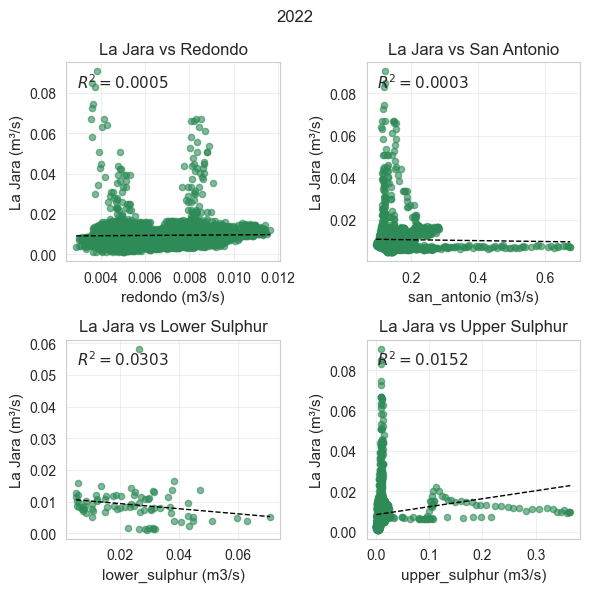

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(6, 6))
fig.suptitle('2022', fontsize=12)
sns.set_style("whitegrid")

# define the pairs: (x_column, subplot_position, title)
pairs = [
    ('redondo (m3/s)', axes[0, 0], 'La Jara vs Redondo'),
    ('san_antonio (m3/s)', axes[0, 1], 'La Jara vs San Antonio'),
    ('lower_sulphur (m3/s)', axes[1, 0], 'La Jara vs Lower Sulphur'),
    ('upper_sulphur (m3/s)', axes[1, 1], 'La Jara vs Upper Sulphur')
]

for x_col, ax, title in pairs:
    # remove NaN values for the regression
    valid_data = merged_2022[[x_col, 'la_jara']].dropna()
    # scatter plot
    ax.scatter(valid_data[x_col], valid_data['la_jara'], alpha=0.6, s=20, color='seagreen')
    # Linear regression
    slope, intercept, r_value, p_value, std_err = linregress(valid_data[x_col], valid_data['la_jara'])
    r2 = r_value**2
    
    # plot regression line
    x_line = np.array([valid_data[x_col].min(), valid_data[x_col].max()])
    y_line = slope * x_line + intercept
    ax.plot(x_line, y_line, color='black', linestyle='--', linewidth=1)
    
    # Labels and title with R² value
    ax.set_xlabel(x_col, fontsize=11)
    ax.set_ylabel('La Jara (m³/s)', fontsize=11)
    ax.set_title(title, fontsize=12)
    ax.text(0.05, 0.95, f'$R^2 = {r2:.4f}$', transform=ax.transAxes, fontsize=11, verticalalignment='top')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 2023

In [13]:
# merge all onto la_jara 2021 index (inner join to only keep dates available in la_jara_2021)
merged_2023 = lajara_2023.copy()
merged_2023 = merged_2023.join([
    redondo[['redondo (m3/s)']],
    san_antonio[['san_antonio (m3/s)']],
    lower_sulphur[['lower_sulphur (m3/s)']],
    upper_sulphur[['upper_sulphur (m3/s)']]
], how='left')

print(merged_2023.head())
print(f"Shape: {merged_2023.shape}")

                      la_jara  redondo (m3/s)  san_antonio (m3/s)  \
2023-03-01 00:00:00  0.025262             NaN            0.059948   
2023-03-01 00:15:00  0.029977             NaN                 NaN   
2023-03-01 00:30:00  0.034701             NaN            0.060114   
2023-03-01 00:45:00  0.034701             NaN                 NaN   
2023-03-01 01:00:00  0.030004             NaN            0.059125   

                     lower_sulphur (m3/s)  upper_sulphur (m3/s)  
2023-03-01 00:00:00                   NaN                   NaN  
2023-03-01 00:15:00                   NaN                   NaN  
2023-03-01 00:30:00                   NaN                   NaN  
2023-03-01 00:45:00                   NaN                   NaN  
2023-03-01 01:00:00                   NaN                   NaN  
Shape: (19304, 5)


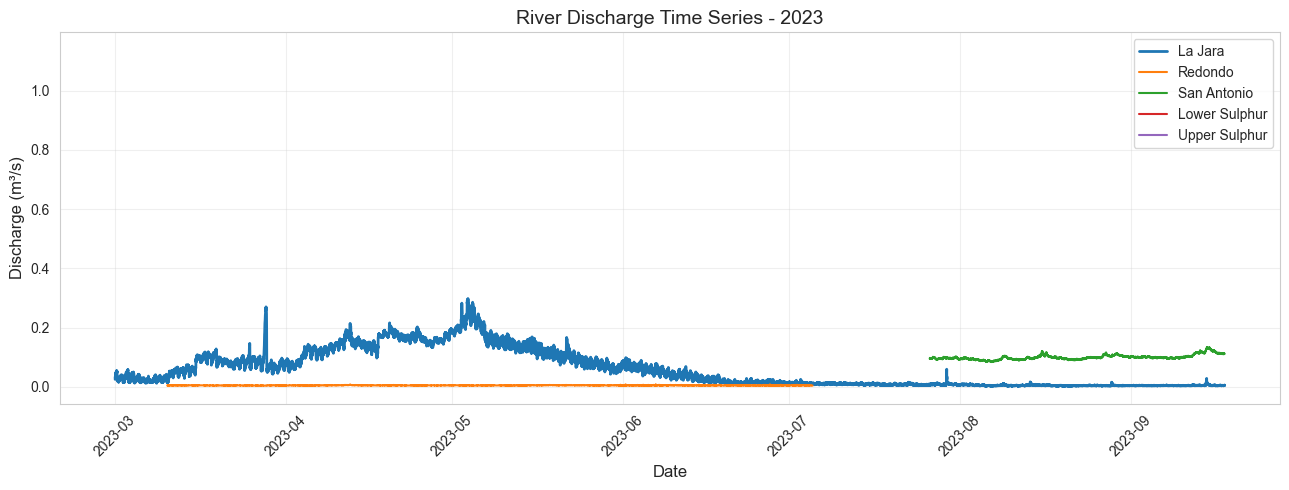

In [14]:
fig, ax = plt.subplots(figsize=(13, 5))
sns.set_style("whitegrid")

ax.plot(merged_2023.index, merged_2023['la_jara'], label='La Jara', linewidth=2)
ax.plot(merged_2023.index, merged_2023['redondo (m3/s)'], label='Redondo', linewidth=1.5)
ax.plot(merged_2023.index, merged_2023['san_antonio (m3/s)'], label='San Antonio', linewidth=1.5)
ax.plot(merged_2023.index, merged_2023['lower_sulphur (m3/s)'], label='Lower Sulphur', linewidth=1.5)
ax.plot(merged_2023.index, merged_2023['upper_sulphur (m3/s)'], label='Upper Sulphur', linewidth=1.5)

ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Discharge (m³/s)', fontsize=12)
ax.set_title('River Discharge Time Series - 2023', fontsize=14)
ax.legend(loc='best')
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

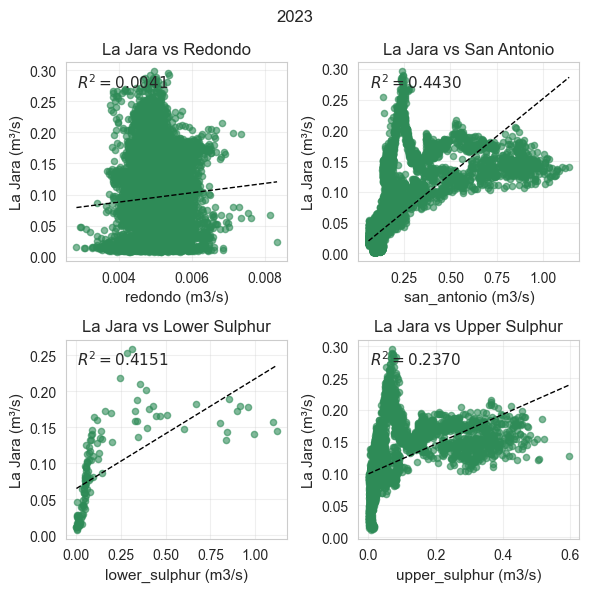

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(6, 6))
fig.suptitle('2023', fontsize=12)
sns.set_style("whitegrid")

# define the pairs: (x_column, subplot_position, title)
pairs = [
    ('redondo (m3/s)', axes[0, 0], 'La Jara vs Redondo'),
    ('san_antonio (m3/s)', axes[0, 1], 'La Jara vs San Antonio'),
    ('lower_sulphur (m3/s)', axes[1, 0], 'La Jara vs Lower Sulphur'),
    ('upper_sulphur (m3/s)', axes[1, 1], 'La Jara vs Upper Sulphur')
]

for x_col, ax, title in pairs:
    # remove NaN values for the regression
    valid_data = merged_2023[[x_col, 'la_jara']].dropna()
    # scatter plot
    ax.scatter(valid_data[x_col], valid_data['la_jara'], alpha=0.6, s=20, color='seagreen')
    # Linear regression
    slope, intercept, r_value, p_value, std_err = linregress(valid_data[x_col], valid_data['la_jara'])
    r2 = r_value**2
    
    # plot regression line
    x_line = np.array([valid_data[x_col].min(), valid_data[x_col].max()])
    y_line = slope * x_line + intercept
    ax.plot(x_line, y_line, color='black', linestyle='--', linewidth=1)
    
    # Labels and title with R² value
    ax.set_xlabel(x_col, fontsize=11)
    ax.set_ylabel('La Jara (m³/s)', fontsize=11)
    ax.set_title(title, fontsize=12)
    ax.text(0.05, 0.95, f'$R^2 = {r2:.4f}$', transform=ax.transAxes, fontsize=11, verticalalignment='top')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## All years

In [16]:
# combine all years
merged_all = pd.concat([merged_2021, merged_2022, merged_2023])

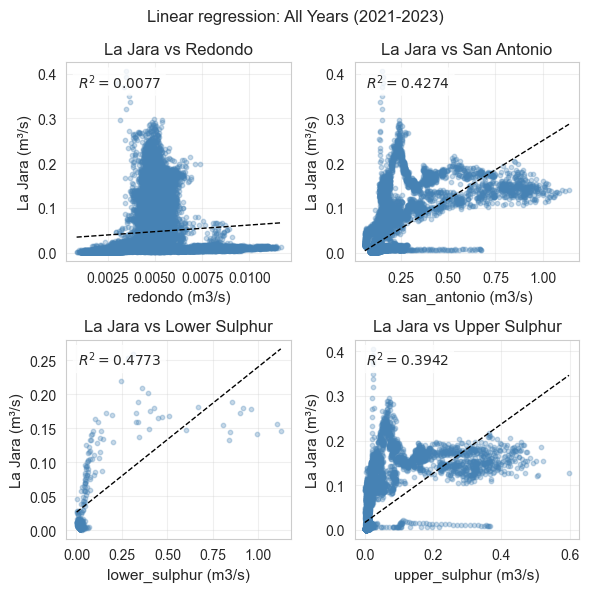

In [30]:
fig, axes = plt.subplots(2, 2, figsize=(6, 6))
sns.set_style("whitegrid")
fig.suptitle('Linear regression: All Years (2021-2023)', fontsize=12)

pairs = [
    ('redondo (m3/s)', axes[0, 0], 'La Jara vs Redondo'),
    ('san_antonio (m3/s)', axes[0, 1], 'La Jara vs San Antonio'),
    ('lower_sulphur (m3/s)', axes[1, 0], 'La Jara vs Lower Sulphur'),
    ('upper_sulphur (m3/s)', axes[1, 1], 'La Jara vs Upper Sulphur')
]

for x_col, ax, title in pairs:
    valid_data = merged_all[[x_col, 'la_jara']].dropna()
    # scatter plot
    ax.scatter(valid_data[x_col], valid_data['la_jara'], alpha=0.3, s=10, color='steelblue')
    
    # linear regression
    slope, intercept, r_value, p_value, std_err = linregress(valid_data[x_col], valid_data['la_jara'])
    r2 = r_value**2
    
    # plot regression line
    x_line = np.array([valid_data[x_col].min(), valid_data[x_col].max()])
    y_line = slope * x_line + intercept
    ax.plot(x_line, y_line, color='black', linestyle='--', linewidth=1)
    
    # Labels and title with R² value
    ax.set_xlabel(x_col, fontsize=11)
    ax.set_ylabel('La Jara (m³/s)', fontsize=11)
    ax.set_title(title, fontsize=12)
    ax.text(0.05, 0.95, f'$R^2 = {r2:.4f}$', 
            transform=ax.transAxes, fontsize=10, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Different curve types

In [44]:
from scipy.optimize import curve_fit

# define exponential function
def exponential(x, a, b):
    return a * np.exp(b * x)

def logarithmic(x, a, b):
    return a * np.log(x) + b

def power_law(x, a, b):
    return a * x**b

Exponential

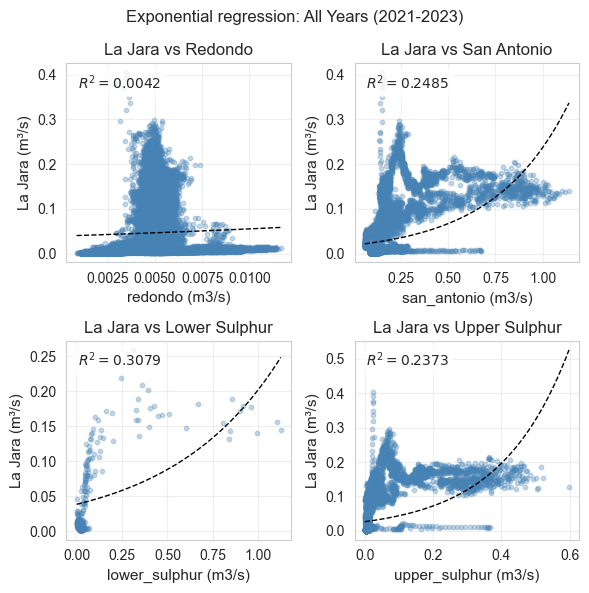

In [31]:
fig, axes = plt.subplots(2, 2, figsize=(6, 6))
sns.set_style("whitegrid")
fig.suptitle('Exponential regression: All Years (2021-2023)', fontsize=12)

pairs = [
    ('redondo (m3/s)', axes[0, 0], 'La Jara vs Redondo'),
    ('san_antonio (m3/s)', axes[0, 1], 'La Jara vs San Antonio'),
    ('lower_sulphur (m3/s)', axes[1, 0], 'La Jara vs Lower Sulphur'),
    ('upper_sulphur (m3/s)', axes[1, 1], 'La Jara vs Upper Sulphur')
]

for x_col, ax, title in pairs:
    valid_data = merged_all[[x_col, 'la_jara']].dropna()
    
    x = valid_data[x_col].values
    y = valid_data['la_jara'].values
    
    # scatter plot
    ax.scatter(x, y, alpha=0.3, s=10, color='steelblue')
    # exponential regression
    try:
        popt, _ = curve_fit(exponential, x, y, p0=[0.01, 0.1], maxfev=5000)
        
        # Calculate R²
        y_pred = exponential(x, *popt)
        residuals = y - y_pred
        ss_res = np.sum(residuals**2)
        ss_tot = np.sum((y - np.mean(y))**2)
        r2 = 1 - (ss_res / ss_tot)
        
        # plot regression line
        x_line = np.linspace(x.min(), x.max(), 100)
        y_line = exponential(x_line, *popt)
        ax.plot(x_line, y_line, color='black', linestyle='--', linewidth=1)
        
        # Labels and title with R² value
        ax.set_xlabel(x_col, fontsize=11)
        ax.set_ylabel('La Jara (m³/s)', fontsize=11)
        ax.set_title(title, fontsize=12)
        ax.text(0.05, 0.95, f'$R^2 = {r2:.4f}$', 
                transform=ax.transAxes, fontsize=10, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    except:
        ax.set_xlabel(x_col, fontsize=11)
        ax.set_ylabel('La Jara (m³/s)', fontsize=11)
        ax.set_title(title + ' (fit failed)', fontsize=12)
    
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [38]:
# print the equations for each subplot
equations = []
for x_col, ax, title in pairs:
    valid_data = merged_all[[x_col, 'la_jara']].dropna()
    x = valid_data[x_col].values
    y = valid_data['la_jara'].values
    try:
        popt, _ = curve_fit(exponential, x, y, p0=[0.01, 0.1], maxfev=5000)
        equation = f"y = {popt[0]:.4f} * e^({popt[1]:.4f} * x)"
        equations.append(equation)
        y_pred = exponential(x, *popt)
        residuals = y - y_pred
        ss_res = np.sum(residuals**2)
        ss_tot = np.sum((y - np.mean(y))**2)
        r2 = 1 - (ss_res / ss_tot)
        print(f"{title}: {equation}, R² = {r2:.4f}")
    except:
        equations.append("Failed to fit")
        print(f"{title}: Failed to fit")

La Jara vs Redondo: y = 0.0392 * e^(34.4606 * x), R² = 0.0042
La Jara vs San Antonio: y = 0.0192 * e^(2.5120 * x), R² = 0.2485
La Jara vs Lower Sulphur: y = 0.0386 * e^(1.6576 * x), R² = 0.3079
La Jara vs Upper Sulphur: y = 0.0268 * e^(4.9820 * x), R² = 0.2373


Logarithmic

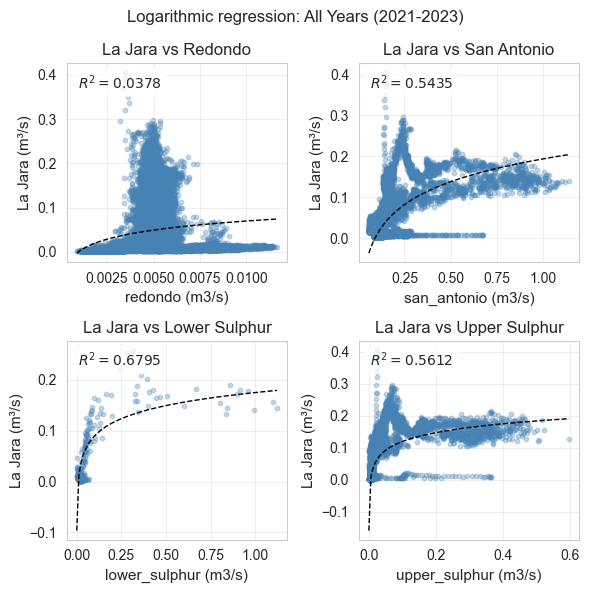

In [45]:
fig, axes = plt.subplots(2, 2, figsize=(6, 6))
sns.set_style("whitegrid")
fig.suptitle('Logarithmic regression: All Years (2021-2023)', fontsize=12)

pairs = [
    ('redondo (m3/s)', axes[0, 0], 'La Jara vs Redondo'),
    ('san_antonio (m3/s)', axes[0, 1], 'La Jara vs San Antonio'),
    ('lower_sulphur (m3/s)', axes[1, 0], 'La Jara vs Lower Sulphur'),
    ('upper_sulphur (m3/s)', axes[1, 1], 'La Jara vs Upper Sulphur')
]

for x_col, ax, title in pairs:
    valid_data = merged_all[[x_col, 'la_jara']].dropna()
    
    x = valid_data[x_col].values
    y = valid_data['la_jara'].values
    
    # scatter plot
    ax.scatter(x, y, alpha=0.3, s=10, color='steelblue')
    # logarithmic regression
    try:
        popt, _ = curve_fit(logarithmic, x, y, p0=[0.01, 0.1], maxfev=5000)
        
        # Calculate R²
        y_pred = logarithmic(x, *popt)
        residuals = y - y_pred
        ss_res = np.sum(residuals**2)
        ss_tot = np.sum((y - np.mean(y))**2)
        r2 = 1 - (ss_res / ss_tot)
        
        # plot regression line
        x_line = np.linspace(x.min(), x.max(), 100)
        y_line = logarithmic(x_line, *popt)
        ax.plot(x_line, y_line, color='black', linestyle='--', linewidth=1)
        
        # Labels and title with R² value
        ax.set_xlabel(x_col, fontsize=11)
        ax.set_ylabel('La Jara (m³/s)', fontsize=11)
        ax.set_title(title, fontsize=12)
        ax.text(0.05, 0.95, f'$R^2 = {r2:.4f}$', 
                transform=ax.transAxes, fontsize=10, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    except:
        ax.set_xlabel(x_col, fontsize=11)
        ax.set_ylabel('La Jara (m³/s)', fontsize=11)
        ax.set_title(title + ' (fit failed)', fontsize=12)
    
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [46]:
# print the equations for each subplot
equations = []
for x_col, ax, title in pairs:
    valid_data = merged_all[[x_col, 'la_jara']].dropna()
    x = valid_data[x_col].values
    y = valid_data['la_jara'].values
    try:
        popt, _ = curve_fit(logarithmic, x, y, p0=[0.01, 0.1], maxfev=5000)
        equation = f"y = {popt[0]:.4f} * ln({popt[1]:.4f} * x)"
        equations.append(equation)
        y_pred = logarithmic(x, *popt)
        residuals = y - y_pred
        ss_res = np.sum(residuals**2)
        ss_tot = np.sum((y - np.mean(y))**2)
        r2 = 1 - (ss_res / ss_tot)
        print(f"{title}: {equation}, R² = {r2:.4f}")
    except:
        equations.append("Failed to fit")
        print(f"{title}: Failed to fit")

La Jara vs Redondo: y = 0.0296 * ln(0.2062 * x), R² = 0.0378
La Jara vs San Antonio: y = 0.0808 * ln(0.1937 * x), R² = 0.5435
La Jara vs Lower Sulphur: y = 0.0371 * ln(0.1752 * x), R² = 0.6795
La Jara vs Upper Sulphur: y = 0.0398 * ln(0.2113 * x), R² = 0.5612


Power Law

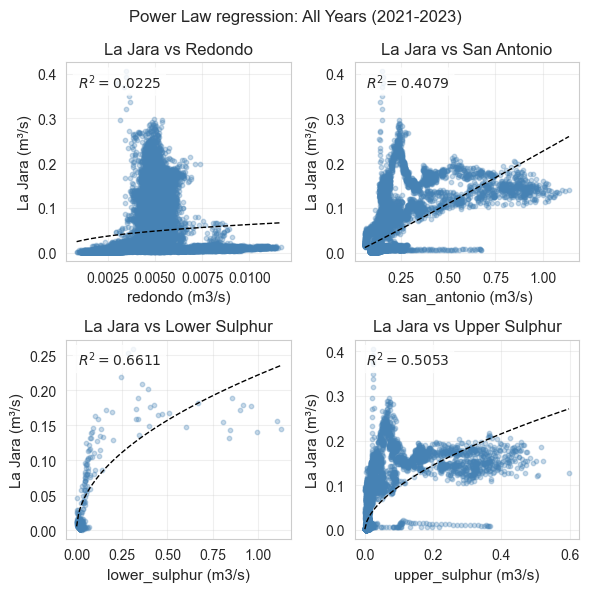

In [33]:
fig, axes = plt.subplots(2, 2, figsize=(6, 6))
sns.set_style("whitegrid")
fig.suptitle('Power Law regression: All Years (2021-2023)', fontsize=12)

pairs = [
    ('redondo (m3/s)', axes[0, 0], 'La Jara vs Redondo'),
    ('san_antonio (m3/s)', axes[0, 1], 'La Jara vs San Antonio'),
    ('lower_sulphur (m3/s)', axes[1, 0], 'La Jara vs Lower Sulphur'),
    ('upper_sulphur (m3/s)', axes[1, 1], 'La Jara vs Upper Sulphur')
]

for x_col, ax, title in pairs:
    valid_data = merged_all[[x_col, 'la_jara']].dropna()
    
    x = valid_data[x_col].values
    y = valid_data['la_jara'].values
    
    # scatter plot
    ax.scatter(x, y, alpha=0.3, s=10, color='steelblue')
    # power law regression
    try:
        popt, _ = curve_fit(power_law, x, y, p0=[0.01, 0.1], maxfev=5000)
        
        # Calculate R²
        y_pred = power_law(x, *popt)
        residuals = y - y_pred
        ss_res = np.sum(residuals**2)
        ss_tot = np.sum((y - np.mean(y))**2)
        r2 = 1 - (ss_res / ss_tot)
        
        # plot regression line
        x_line = np.linspace(x.min(), x.max(), 100)
        y_line = power_law(x_line, *popt)
        ax.plot(x_line, y_line, color='black', linestyle='--', linewidth=1)
        
        # Labels and title with R² value
        ax.set_xlabel(x_col, fontsize=11)
        ax.set_ylabel('La Jara (m³/s)', fontsize=11)
        ax.set_title(title, fontsize=12)
        ax.text(0.05, 0.95, f'$R^2 = {r2:.4f}$', 
                transform=ax.transAxes, fontsize=10, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    except:
        ax.set_xlabel(x_col, fontsize=11)
        ax.set_ylabel('La Jara (m³/s)', fontsize=11)
        ax.set_title(title + ' (fit failed)', fontsize=12)
    
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [40]:
# print the equations for each subplot
equations = []
for x_col, ax, title in pairs:
    valid_data = merged_all[[x_col, 'la_jara']].dropna()
    x = valid_data[x_col].values
    y = valid_data['la_jara'].values
    try:
        popt, _ = curve_fit(power_law, x, y, p0=[0.01, 0.1], maxfev=5000)
        equation = f"y = {popt[0]:.4f} * x^{popt[1]:.4f}"
        equations.append(equation)
        y_pred = power_law(x, *popt)
        residuals = y - y_pred
        ss_res = np.sum(residuals**2)
        ss_tot = np.sum((y - np.mean(y))**2)
        r2 = 1 - (ss_res / ss_tot)
        print(f"{title}: {equation}, R² = {r2:.4f}")
    except:
        equations.append("Failed to fit")
        print(f"{title}: Failed to fit")

La Jara vs Redondo: y = 0.3720 * x^0.3865, R² = 0.0225
La Jara vs San Antonio: y = 0.2263 * x^1.0436, R² = 0.4079
La Jara vs Lower Sulphur: y = 0.2221 * x^0.4990, R² = 0.6611
La Jara vs Upper Sulphur: y = 0.3638 * x^0.5724, R² = 0.5053
